In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [60]:
data = pd.read_csv('../M1_final.csv')

In [61]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [62]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)

### Temporal lag feature

In [63]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified train test split

In [64]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind direction transformer

In [65]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew Point Transformer

In [66]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [67]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

## Naive Bayes model

In [68]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

## Create pipeline

In [69]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train NaiveBayes', nb_model)
])

## Hyperparameter tuning with Optuna

In [70]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB

### Naive Bayes Variants Being Explored:

1. **GaussianNB** - Assumes features follow normal distribution (best for continuous features)
2. **MultinomialNB** - For discrete count data (requires non-negative features)
3. **ComplementNB** - Improved MultinomialNB, better for imbalanced datasets
4. **BernoulliNB** - For binary/boolean features

Optuna will automatically explore all variants and their hyperparameters to find the best combination!

In [71]:
def objective(trial):
    # Let Optuna choose which Naive Bayes variant to use
    nb_type = trial.suggest_categorical('nb_type', ['GaussianNB', 'MultinomialNB', 'ComplementNB', 'BernoulliNB'])
    
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import MinMaxScaler
    
    # Optimize class priors - important for imbalanced datasets!
    # If use_custom_priors=True, optimize the prior for class 1 (delayed)
    use_custom_priors = trial.suggest_categorical('use_custom_priors', [True, False])
    
    if use_custom_priors:
        # Suggest prior probability for class 1 (delayed flights)
        # The prior for class 0 will be (1 - class_1_prior)
        class_1_prior = trial.suggest_float('class_1_prior', 0.2, 0.8)
        priors = [1 - class_1_prior, class_1_prior]
    else:
        priors = None  # Use empirical priors from training data
    
    if nb_type == 'GaussianNB':
        # GaussianNB hyperparameters (works with any features)
        var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-5, log=True)
        nb_model = GaussianNB(var_smoothing=var_smoothing, priors=priors)
        
        # GaussianNB doesn't need scaling
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Train NaiveBayes', nb_model)
        ])
        
    elif nb_type == 'MultinomialNB':
        # MultinomialNB hyperparameters (requires non-negative features)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        
        # MultinomialNB uses class_prior instead of priors
        nb_model = MultinomialNB(
            alpha=alpha, 
            fit_prior=fit_prior,
            class_prior=priors if not fit_prior else None
        )
        
        # Add MinMaxScaler to ensure non-negative features
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Scaler', MinMaxScaler()),  # Scale to [0, 1]
            ('Train NaiveBayes', nb_model)
        ])
        
    elif nb_type == 'ComplementNB':
        # ComplementNB hyperparameters (good for imbalanced data, requires non-negative)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        norm = trial.suggest_categorical('norm', [True, False])
        
        # ComplementNB uses class_prior instead of priors
        nb_model = ComplementNB(
            alpha=alpha, 
            fit_prior=fit_prior, 
            norm=norm,
            class_prior=priors if not fit_prior else None
        )
        
        # Add MinMaxScaler to ensure non-negative features
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Scaler', MinMaxScaler()),  # Scale to [0, 1]
            ('Train NaiveBayes', nb_model)
        ])
        
    else:  # BernoulliNB
        # BernoulliNB hyperparameters (for binary features)
        alpha = trial.suggest_float('alpha', 0.01, 10.0, log=True)
        binarize = trial.suggest_float('binarize', 0.0, 1.0)
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        
        # BernoulliNB uses class_prior instead of priors
        nb_model = BernoulliNB(
            alpha=alpha, 
            binarize=binarize, 
            fit_prior=fit_prior,
            class_prior=priors if not fit_prior else None
        )
        
        # BernoulliNB works with any features (it binarizes internally)
        trial_pipe = Pipeline([
            ('Preprocessor', preprocessor),
            ('Train NaiveBayes', nb_model)
        ])
    
    # Perform cross-validation
    # Using accuracy as the metric
    try:
        cv_scores = cross_val_score(
            trial_pipe, 
            x_train, 
            y_train, 
            cv=5, 
            scoring='accuracy',
            n_jobs=-1
        )
        return cv_scores.mean()
    except Exception as e:
        # If any error occurs, return a very low score
        print(f"Error with {nb_type}: {str(e)}")
        return 0.0

In [72]:
# Create Optuna study
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='NaiveBayes_Hyperparameter_Tuning',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization with more trials to explore all variants
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("\n" + "="*50)
print("Optimization completed!")
print("="*50)

[I 2025-10-29 02:29:59,375] A new study created in memory with name: NaiveBayes_Hyperparameter_Tuning
Best trial: 0. Best value: 0.872397:   1%|          | 1/100 [00:00<00:35,  2.82it/s]

[I 2025-10-29 02:29:59,728] Trial 0 finished with value: 0.872397225811089 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.23485016730091968, 'alpha': 3.9676050770529883, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   2%|▏         | 2/100 [00:00<00:34,  2.84it/s]

[I 2025-10-29 02:30:00,080] Trial 1 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.08179499475211674, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   3%|▎         | 3/100 [00:01<00:34,  2.84it/s]

[I 2025-10-29 02:30:00,431] Trial 2 finished with value: 0.7892640683066303 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.267398652378039, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   4%|▍         | 4/100 [00:01<00:33,  2.87it/s]

[I 2025-10-29 02:30:00,773] Trial 3 finished with value: 0.7888674765116093 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 7.886714129990489, 'fit_prior': True, 'norm': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   5%|▌         | 5/100 [00:01<00:33,  2.86it/s]

[I 2025-10-29 02:30:01,125] Trial 4 finished with value: 0.7891153448476057 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.5975133706123892, 'alpha': 0.08612579192594885, 'fit_prior': False, 'norm': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   6%|▌         | 6/100 [00:02<00:33,  2.85it/s]

[I 2025-10-29 02:30:01,480] Trial 5 finished with value: 0.848751227945364 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3175897174514871, 'alpha': 0.013667272915456224, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   7%|▋         | 7/100 [00:02<00:32,  2.85it/s]

[I 2025-10-29 02:30:01,832] Trial 6 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.6813181884524239, 'alpha': 0.01673601016782578, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   8%|▊         | 8/100 [00:02<00:31,  2.91it/s]

[I 2025-10-29 02:30:02,161] Trial 7 finished with value: 0.8565344263966936 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 0.016677615430197915, 'fit_prior': True, 'norm': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:   9%|▉         | 9/100 [00:03<00:31,  2.89it/s]

[I 2025-10-29 02:30:02,510] Trial 8 finished with value: 0.7905524110734101 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.7323276455457961, 'var_smoothing': 2.0207122587167317e-09}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  10%|█         | 10/100 [00:03<00:31,  2.90it/s]

[I 2025-10-29 02:30:02,852] Trial 9 finished with value: 0.7891153448476057 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': True, 'class_1_prior': 0.5136396976291965, 'alpha': 0.19170041589170655, 'fit_prior': False, 'norm': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  11%|█         | 11/100 [00:03<00:31,  2.86it/s]

[I 2025-10-29 02:30:03,215] Trial 10 finished with value: 0.8228744887784686 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.20452839158977593, 'alpha': 1.335929285535435, 'binarize': 0.33161751444757637, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  12%|█▏        | 12/100 [00:04<00:30,  2.88it/s]

[I 2025-10-29 02:30:03,555] Trial 11 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.6190898499660049, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  13%|█▎        | 13/100 [00:04<00:30,  2.85it/s]

[I 2025-10-29 02:30:03,913] Trial 12 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.07906277592929153, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  14%|█▍        | 14/100 [00:04<00:30,  2.81it/s]

[I 2025-10-29 02:30:04,280] Trial 13 finished with value: 0.8553937258212259 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 7.674592970503708e-06}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  15%|█▌        | 15/100 [00:05<00:29,  2.85it/s]

[I 2025-10-29 02:30:04,620] Trial 14 finished with value: 0.5246439465288543 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.353014215455331, 'alpha': 8.099931342625656, 'binarize': 0.9977542884314977, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  16%|█▌        | 16/100 [00:05<00:29,  2.90it/s]

[I 2025-10-29 02:30:04,953] Trial 15 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.06251116565293881, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  17%|█▋        | 17/100 [00:05<00:28,  2.90it/s]

[I 2025-10-29 02:30:05,298] Trial 16 finished with value: 0.838192083523016 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.38897356853274434, 'alpha': 0.32305787891550275, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  18%|█▊        | 18/100 [00:06<00:28,  2.85it/s]

[I 2025-10-29 02:30:05,661] Trial 17 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.683717233779464, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  19%|█▉        | 19/100 [00:06<00:28,  2.84it/s]

[I 2025-10-29 02:30:06,016] Trial 18 finished with value: 0.8392828737638377 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 2.1136004641317015e-12}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  20%|██        | 20/100 [00:06<00:27,  2.87it/s]

[I 2025-10-29 02:30:06,356] Trial 19 finished with value: 0.8028462037980757 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.22040910446487794, 'alpha': 3.142870630374243, 'binarize': 0.14800095597336144, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  21%|██        | 21/100 [00:07<00:27,  2.87it/s]

[I 2025-10-29 02:30:06,705] Trial 20 finished with value: 0.7889666213885812 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.9664628244881006, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  22%|██▏       | 22/100 [00:07<00:27,  2.88it/s]

[I 2025-10-29 02:30:07,048] Trial 21 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.879555467818434, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  23%|██▎       | 23/100 [00:08<00:26,  2.86it/s]

[I 2025-10-29 02:30:07,403] Trial 22 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.7601823641187484, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  24%|██▍       | 24/100 [00:08<00:26,  2.85it/s]

[I 2025-10-29 02:30:07,757] Trial 23 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 4.605994473159585, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  25%|██▌       | 25/100 [00:08<00:25,  2.96it/s]

[I 2025-10-29 02:30:08,065] Trial 24 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.9038144004298891, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  26%|██▌       | 26/100 [00:09<00:26,  2.83it/s]

[I 2025-10-29 02:30:08,455] Trial 25 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.4890081276037965, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  27%|██▋       | 27/100 [00:09<00:26,  2.81it/s]

[I 2025-10-29 02:30:08,818] Trial 26 finished with value: 0.8142984384896902 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.4739401295734177, 'alpha': 0.5024521187097875, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  28%|██▊       | 28/100 [00:09<00:25,  2.82it/s]

[I 2025-10-29 02:30:09,170] Trial 27 finished with value: 0.753288755614452 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': False, 'alpha': 1.872615243830784, 'binarize': 0.809536765842115, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  29%|██▉       | 29/100 [00:10<00:25,  2.77it/s]

[I 2025-10-29 02:30:09,542] Trial 28 finished with value: 0.6259216363512375 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.45900282460589753, 'var_smoothing': 6.3373679932301074e-06}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  30%|███       | 30/100 [00:10<00:25,  2.77it/s]

[I 2025-10-29 02:30:09,905] Trial 29 finished with value: 0.8702655065155597 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 8.448048376144301, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  31%|███       | 31/100 [00:10<00:25,  2.75it/s]

[I 2025-10-29 02:30:10,273] Trial 30 finished with value: 0.7890161876835007 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.8509992666358992, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  32%|███▏      | 32/100 [00:11<00:24,  2.77it/s]

[I 2025-10-29 02:30:10,628] Trial 31 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 4.948548892270684, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  33%|███▎      | 33/100 [00:11<00:23,  2.82it/s]

[I 2025-10-29 02:30:10,971] Trial 32 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.969312415012516, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  34%|███▍      | 34/100 [00:11<00:23,  2.84it/s]

[I 2025-10-29 02:30:11,315] Trial 33 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.393229781592465, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  35%|███▌      | 35/100 [00:12<00:24,  2.65it/s]

[I 2025-10-29 02:30:11,755] Trial 34 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.1994560972296247, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  36%|███▌      | 36/100 [00:12<00:24,  2.64it/s]

[I 2025-10-29 02:30:12,137] Trial 35 finished with value: 0.8574763334457606 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 5.539802080501232, 'fit_prior': True, 'norm': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  37%|███▋      | 37/100 [00:13<00:24,  2.62it/s]

[I 2025-10-29 02:30:12,523] Trial 36 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.343024041801541, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  38%|███▊      | 38/100 [00:13<00:23,  2.64it/s]

[I 2025-10-29 02:30:12,897] Trial 37 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.29035029069892226, 'alpha': 2.663572283404698, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  39%|███▉      | 39/100 [00:13<00:22,  2.71it/s]

[I 2025-10-29 02:30:13,242] Trial 38 finished with value: 0.8575258383050144 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 9.634905910250627, 'fit_prior': False, 'norm': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  40%|████      | 40/100 [00:14<00:21,  2.74it/s]

[I 2025-10-29 02:30:13,598] Trial 39 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.5825030353150061, 'alpha': 6.2377358087736825, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  41%|████      | 41/100 [00:14<00:21,  2.78it/s]

[I 2025-10-29 02:30:13,942] Trial 40 finished with value: 0.7891649234296583 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.7856450054417286, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  42%|████▏     | 42/100 [00:14<00:21,  2.74it/s]

[I 2025-10-29 02:30:14,322] Trial 41 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.838105423656974, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  43%|████▎     | 43/100 [00:15<00:20,  2.80it/s]

[I 2025-10-29 02:30:14,660] Trial 42 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.091810048423848, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  44%|████▍     | 44/100 [00:15<00:18,  2.97it/s]

[I 2025-10-29 02:30:14,950] Trial 43 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.5797614217931132, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  45%|████▌     | 45/100 [00:15<00:17,  3.14it/s]

[I 2025-10-29 02:30:15,227] Trial 44 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.8981291965414121, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  46%|████▌     | 46/100 [00:16<00:15,  3.51it/s]

[I 2025-10-29 02:30:15,433] Trial 45 finished with value: 0.783066720975795 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': True, 'class_1_prior': 0.7843541733207561, 'var_smoothing': 1.4941634067167822e-12}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  47%|████▋     | 47/100 [00:16<00:14,  3.55it/s]

[I 2025-10-29 02:30:15,708] Trial 46 finished with value: 0.7892640928808965 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 3.5396646586962857, 'fit_prior': True, 'norm': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  48%|████▊     | 48/100 [00:16<00:14,  3.62it/s]

[I 2025-10-29 02:30:15,971] Trial 47 finished with value: 0.4811673390800255 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': False, 'alpha': 6.364865246043056, 'binarize': 0.6224543798910074, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  49%|████▉     | 49/100 [00:16<00:14,  3.61it/s]

[I 2025-10-29 02:30:16,250] Trial 48 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.40819058772059463, 'alpha': 1.441976874533158, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  50%|█████     | 50/100 [00:17<00:13,  3.61it/s]

[I 2025-10-29 02:30:16,526] Trial 49 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.6192452614379507, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  51%|█████     | 51/100 [00:17<00:13,  3.58it/s]

[I 2025-10-29 02:30:16,813] Trial 50 finished with value: 0.8652094618297138 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2663454369599618, 'alpha': 0.2304968818774013, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  52%|█████▏    | 52/100 [00:17<00:14,  3.34it/s]

[I 2025-10-29 02:30:17,157] Trial 51 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.153333865153259, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  53%|█████▎    | 53/100 [00:18<00:14,  3.35it/s]

[I 2025-10-29 02:30:17,453] Trial 52 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 4.213374062464967, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  54%|█████▍    | 54/100 [00:18<00:13,  3.32it/s]

[I 2025-10-29 02:30:17,760] Trial 53 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.6095559561097565, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  55%|█████▌    | 55/100 [00:18<00:13,  3.30it/s]

[I 2025-10-29 02:30:18,068] Trial 54 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.02745585216424085, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  56%|█████▌    | 56/100 [00:18<00:13,  3.29it/s]

[I 2025-10-29 02:30:18,372] Trial 55 finished with value: 0.8447855065892822 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 7.622977653861337e-09}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  57%|█████▋    | 57/100 [00:19<00:13,  3.28it/s]

[I 2025-10-29 02:30:18,681] Trial 56 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.2424208016614802, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  58%|█████▊    | 58/100 [00:19<00:12,  3.28it/s]

[I 2025-10-29 02:30:18,988] Trial 57 finished with value: 0.8037385814136224 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': False, 'alpha': 1.8423287303526499, 'binarize': 0.005458575377312813, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  59%|█████▉    | 59/100 [00:19<00:12,  3.31it/s]

[I 2025-10-29 02:30:19,283] Trial 58 finished with value: 0.6422307535883036 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.5783114531549671, 'alpha': 0.40270231426908387, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  60%|██████    | 60/100 [00:20<00:11,  3.39it/s]

[I 2025-10-29 02:30:19,560] Trial 59 finished with value: 0.8573771762816556 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 6.2460712731272165, 'fit_prior': True, 'norm': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  61%|██████    | 61/100 [00:20<00:11,  3.31it/s]

[I 2025-10-29 02:30:19,878] Trial 60 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.409512215870741, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  62%|██████▏   | 62/100 [00:20<00:11,  3.36it/s]

[I 2025-10-29 02:30:20,166] Trial 61 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.32218492198258886, 'alpha': 2.5684553283439566, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  63%|██████▎   | 63/100 [00:21<00:10,  3.43it/s]

[I 2025-10-29 02:30:20,444] Trial 62 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2672882435369268, 'alpha': 2.990840844550449, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  64%|██████▍   | 64/100 [00:21<00:10,  3.49it/s]

[I 2025-10-29 02:30:20,720] Trial 63 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2557248883858205, 'alpha': 1.6187451082698798, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  65%|██████▌   | 65/100 [00:21<00:09,  3.52it/s]

[I 2025-10-29 02:30:20,997] Trial 64 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.40537223590660165, 'alpha': 1.099297768246586, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  66%|██████▌   | 66/100 [00:21<00:09,  3.40it/s]

[I 2025-10-29 02:30:21,314] Trial 65 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3062161423085862, 'alpha': 4.122192593128618, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  67%|██████▋   | 67/100 [00:22<00:09,  3.50it/s]

[I 2025-10-29 02:30:21,581] Trial 66 finished with value: 0.8397783032575035 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.3678898196913975, 'alpha': 0.6706971447705866, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  68%|██████▊   | 68/100 [00:22<00:08,  3.63it/s]

[I 2025-10-29 02:30:21,833] Trial 67 finished with value: 0.8399769370511742 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 8.271394546548106e-10}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  69%|██████▉   | 69/100 [00:22<00:08,  3.76it/s]

[I 2025-10-29 02:30:22,078] Trial 68 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2018956884547979, 'alpha': 2.10600610528476, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  70%|███████   | 70/100 [00:22<00:08,  3.67it/s]

[I 2025-10-29 02:30:22,365] Trial 69 finished with value: 0.8072688590598254 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': False, 'alpha': 4.867028575756601, 'binarize': 0.4768583505976384, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  71%|███████   | 71/100 [00:23<00:07,  3.66it/s]

[I 2025-10-29 02:30:22,641] Trial 70 finished with value: 0.7889666213885812 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 7.135513370367063, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  72%|███████▏  | 72/100 [00:23<00:07,  3.84it/s]

[I 2025-10-29 02:30:22,872] Trial 71 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.8327180372577496, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  73%|███████▎  | 73/100 [00:23<00:06,  3.94it/s]

[I 2025-10-29 02:30:23,109] Trial 72 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.5001612178769856, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  74%|███████▍  | 74/100 [00:23<00:06,  4.10it/s]

[I 2025-10-29 02:30:23,331] Trial 73 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.5689305686279185, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  75%|███████▌  | 75/100 [00:24<00:06,  4.08it/s]

[I 2025-10-29 02:30:23,577] Trial 74 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.444322953519925, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  76%|███████▌  | 76/100 [00:24<00:05,  4.12it/s]

[I 2025-10-29 02:30:23,815] Trial 75 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 4.981986492964946, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  77%|███████▋  | 77/100 [00:24<00:05,  4.16it/s]

[I 2025-10-29 02:30:24,049] Trial 76 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.12711761165172086, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  78%|███████▊  | 78/100 [00:24<00:05,  4.17it/s]

[I 2025-10-29 02:30:24,289] Trial 77 finished with value: 0.8568814764710616 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 3.0474987805870977, 'fit_prior': True, 'norm': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  79%|███████▉  | 79/100 [00:25<00:05,  3.93it/s]

[I 2025-10-29 02:30:24,577] Trial 78 finished with value: 0.7496552660502213 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.5266865024232392, 'alpha': 2.1404279078431325, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  80%|████████  | 80/100 [00:25<00:05,  3.97it/s]

[I 2025-10-29 02:30:24,822] Trial 79 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.92177211694436, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  81%|████████  | 81/100 [00:25<00:04,  4.03it/s]

[I 2025-10-29 02:30:25,063] Trial 80 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.0624172152006934, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  82%|████████▏ | 82/100 [00:25<00:04,  4.02it/s]

[I 2025-10-29 02:30:25,314] Trial 81 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.9813130336023723, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  83%|████████▎ | 83/100 [00:26<00:04,  4.01it/s]

[I 2025-10-29 02:30:25,565] Trial 82 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.3865196355724316, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  84%|████████▍ | 84/100 [00:26<00:04,  3.94it/s]

[I 2025-10-29 02:30:25,828] Trial 83 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.346330539561838, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  85%|████████▌ | 85/100 [00:26<00:03,  3.99it/s]

[I 2025-10-29 02:30:26,072] Trial 84 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.173253804837736, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  86%|████████▌ | 86/100 [00:26<00:03,  3.91it/s]

[I 2025-10-29 02:30:26,340] Trial 85 finished with value: 0.8586657279296979 and parameters: {'nb_type': 'GaussianNB', 'use_custom_priors': False, 'var_smoothing': 5.4139716809166825e-08}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  87%|████████▋ | 87/100 [00:27<00:03,  3.88it/s]

[I 2025-10-29 02:30:26,602] Trial 86 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 0.7502644628283284, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  88%|████████▊ | 88/100 [00:27<00:03,  3.98it/s]

[I 2025-10-29 02:30:26,839] Trial 87 finished with value: 0.7535863131166989 and parameters: {'nb_type': 'BernoulliNB', 'use_custom_priors': True, 'class_1_prior': 0.4289940905488516, 'alpha': 1.7034780632866482, 'binarize': 0.6826956675891347, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  89%|████████▉ | 89/100 [00:27<00:02,  3.86it/s]

[I 2025-10-29 02:30:27,115] Trial 88 finished with value: 0.7891153571347389 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 5.761758021489821, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  90%|█████████ | 90/100 [00:27<00:02,  3.98it/s]

[I 2025-10-29 02:30:27,348] Trial 89 finished with value: 0.8702655065155597 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 9.576961297769499, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  91%|█████████ | 91/100 [00:28<00:02,  3.99it/s]

[I 2025-10-29 02:30:27,599] Trial 90 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.2927457141926278, 'alpha': 4.124121906653182, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  92%|█████████▏| 92/100 [00:28<00:02,  3.77it/s]

[I 2025-10-29 02:30:27,898] Trial 91 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.687114440921291, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  93%|█████████▎| 93/100 [00:28<00:01,  3.92it/s]

[I 2025-10-29 02:30:28,129] Trial 92 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.367376821527879, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  94%|█████████▍| 94/100 [00:29<00:01,  3.88it/s]

[I 2025-10-29 02:30:28,388] Trial 93 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 1.86833607632208, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  95%|█████████▌| 95/100 [00:29<00:01,  3.70it/s]

[I 2025-10-29 02:30:28,691] Trial 94 finished with value: 0.8702655188026928 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 3.2253956444741836, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  96%|█████████▌| 96/100 [00:29<00:01,  3.83it/s]

[I 2025-10-29 02:30:28,931] Trial 95 finished with value: 0.7889666213885812 and parameters: {'nb_type': 'ComplementNB', 'use_custom_priors': False, 'alpha': 1.3557010598526518, 'fit_prior': True, 'norm': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  97%|█████████▋| 97/100 [00:29<00:00,  3.97it/s]

[I 2025-10-29 02:30:29,161] Trial 96 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 4.7228362706843585, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  98%|█████████▊| 98/100 [00:30<00:00,  3.91it/s]

[I 2025-10-29 02:30:29,427] Trial 97 finished with value: 0.7892640683066303 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 2.6909118900645765, 'fit_prior': False}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397:  99%|█████████▉| 99/100 [00:30<00:00,  3.99it/s]

[I 2025-10-29 02:30:29,665] Trial 98 finished with value: 0.8703150973847451 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.6456811006454575, 'alpha': 2.1638474519212805, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.


Best trial: 0. Best value: 0.872397: 100%|██████████| 100/100 [00:30<00:00,  3.28it/s]

[I 2025-10-29 02:30:29,910] Trial 99 finished with value: 0.870315085097612 and parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': False, 'alpha': 7.458763708052698, 'fit_prior': True}. Best is trial 0 with value: 0.872397225811089.

Optimization completed!


## Results

In [73]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f}")
print(f"  Number: {study.best_trial.number}")
print(f"\nBest Naive Bayes Variant: {study.best_params['nb_type']}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Show distribution of variants tried
print("\n" + "="*50)
print("Variant Performance Summary:")
print("="*50)
variant_scores = {}
for trial in study.trials:
    if trial.state.name == 'COMPLETE':
        nb_type = trial.params['nb_type']
        if nb_type not in variant_scores:
            variant_scores[nb_type] = []
        variant_scores[nb_type].append(trial.value)

for variant, scores in sorted(variant_scores.items()):
    avg_score = sum(scores) / len(scores)
    max_score = max(scores)
    print(f"{variant:15s} - Avg: {avg_score:.4f}, Max: {max_score:.4f}, Trials: {len(scores)}")

Best Trial:
  Value (Accuracy): 0.8724
  Number: 0

Best Naive Bayes Variant: MultinomialNB

Best Hyperparameters:
  nb_type: MultinomialNB
  use_custom_priors: True
  class_1_prior: 0.23485016730091968
  alpha: 3.9676050770529883
  fit_prior: False

Variant Performance Summary:
BernoulliNB     - Avg: 0.7187, Max: 0.8229, Trials: 8
ComplementNB    - Avg: 0.8231, Max: 0.8575, Trials: 10
GaussianNB      - Avg: 0.8047, Max: 0.8587, Trials: 8
MultinomialNB   - Avg: 0.8560, Max: 0.8724, Trials: 74


## Training the model with best hyperparameters

In [74]:
# Train final model with best parameters
from sklearn.preprocessing import MinMaxScaler

best_params = study.best_params
nb_type = best_params['nb_type']

# Get priors if custom priors were used
if best_params.get('use_custom_priors', False):
    class_1_prior = best_params['class_1_prior']
    priors = [1 - class_1_prior, class_1_prior]
else:
    priors = None

# Recreate the best model based on the variant and parameters
if nb_type == 'GaussianNB':
    best_nb_model = GaussianNB(
        var_smoothing=best_params['var_smoothing'],
        priors=priors
    )
    # GaussianNB doesn't need scaling
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Train NaiveBayes', best_nb_model)
    ])
    
elif nb_type == 'MultinomialNB':
    fit_prior = best_params['fit_prior']
    best_nb_model = MultinomialNB(
        alpha=best_params['alpha'],
        fit_prior=fit_prior,
        class_prior=priors if not fit_prior else None
    )
    # MultinomialNB needs non-negative features
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Scaler', MinMaxScaler()),
        ('Train NaiveBayes', best_nb_model)
    ])
    
elif nb_type == 'ComplementNB':
    fit_prior = best_params['fit_prior']
    best_nb_model = ComplementNB(
        alpha=best_params['alpha'],
        fit_prior=fit_prior,
        norm=best_params['norm'],
        class_prior=priors if not fit_prior else None
    )
    # ComplementNB needs non-negative features
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Scaler', MinMaxScaler()),
        ('Train NaiveBayes', best_nb_model)
    ])
    
else:  # BernoulliNB
    fit_prior = best_params['fit_prior']
    best_nb_model = BernoulliNB(
        alpha=best_params['alpha'],
        binarize=best_params['binarize'],
        fit_prior=fit_prior,
        class_prior=priors if not fit_prior else None
    )
    # BernoulliNB works without scaling
    final_pipe = Pipeline([
        ('Preprocessor', preprocessor),
        ('Train NaiveBayes', best_nb_model)
    ])

# Fit the model
print(f"Training final model with best variant: {nb_type}")
print("Best parameters:", best_params)
if priors:
    print(f"Using custom priors: [Not Delayed: {priors[0]:.4f}, Delayed: {priors[1]:.4f}]")
else:
    print("Using empirical priors from training data")
final_pipe.fit(x_train, y_train)

Training final model with best variant: MultinomialNB
Best parameters: {'nb_type': 'MultinomialNB', 'use_custom_priors': True, 'class_1_prior': 0.23485016730091968, 'alpha': 3.9676050770529883, 'fit_prior': False}
Using custom priors: [Not Delayed: 0.7651, Delayed: 0.2349]


,steps,"[('Preprocessor', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluating on test set

In [75]:
# Make predictions on test set
y_pred = final_pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("Test Set Performance")
print("="*50)
print(f"Accuracy:  {100 * accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*50)

Test Set Performance
Accuracy:  87.4624
Precision: 0.6393
Recall:    0.2322
F1 Score:  0.3406


### Classification report

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      7440
           1       0.64      0.23      0.34      1206

    accuracy                           0.87      8646
   macro avg       0.76      0.61      0.64      8646
weighted avg       0.85      0.87      0.85      8646



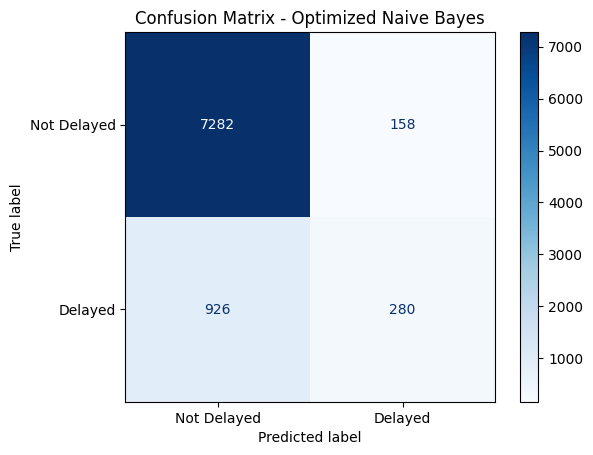

In [77]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Optimized Naive Bayes')
plt.show()

## ROC AUC Score

ROC AUC Score: 86.5397


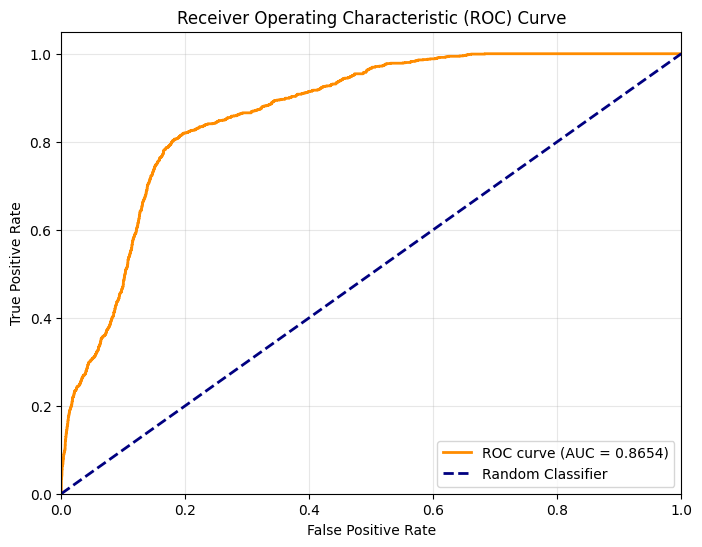

In [78]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = final_pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Specificity and Sensitivity

In [79]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9788 or 97.88%
Sensitivity (True Positive Rate): 0.2322 or 23.22%


## Save the trained model

In [80]:
# import pickle
# import os
# from datetime import datetime

# # Create the saved_models directory if it doesn't exist
# save_dir = '../saved_models/'
# os.makedirs(save_dir, exist_ok=True)

# # Create a timestamp for the filename
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# nb_variant = study.best_params['nb_type']
# model_filename = os.path.join(save_dir, f'NaiveBayes_{nb_variant}_model_{timestamp}.pkl')

# # Save the entire pipeline (preprocessor + model)
# with open(model_filename, 'wb') as file:
#     pickle.dump(final_pipe, file)

# print(f"Model saved successfully as: {model_filename}")
# print(f"Best Naive Bayes variant: {nb_variant}")

# # Also save the best parameters for reference
# params_filename = os.path.join(save_dir, f'NB_{nb_variant}_BestParams_JFKFlightTakeoff_{timestamp}.pkl')
# with open(params_filename, 'wb') as file:
#     pickle.dump(study.best_params, file)

# print(f"Best parameters saved as: {params_filename}")